<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [27]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-03 02:14:30--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  50.3MB/s    in 4.6s    

2026-04-03 02:14:35 (44.3 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [28]:
!pip install pandas

In [29]:
!pip install matplotlib

In [30]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [31]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [32]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [33]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [34]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


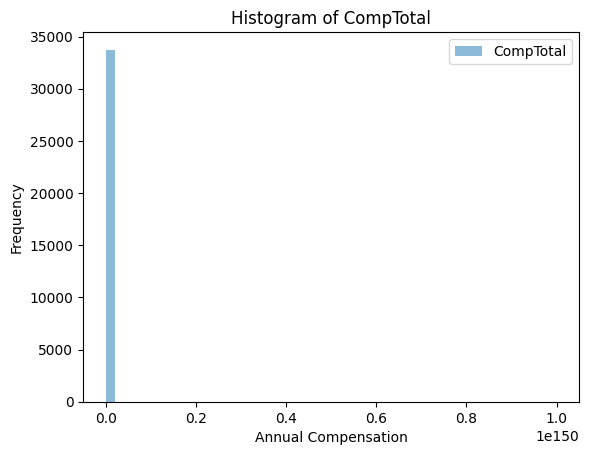

In [35]:
## Write your code here
df_comp = pd.read_sql("SELECT CompTotal FROM main", conn)

df_comp.plot.hist(bins=50, alpha=0.5)
plt.title('Histogram of CompTotal')
plt.xlabel('Annual Compensation')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


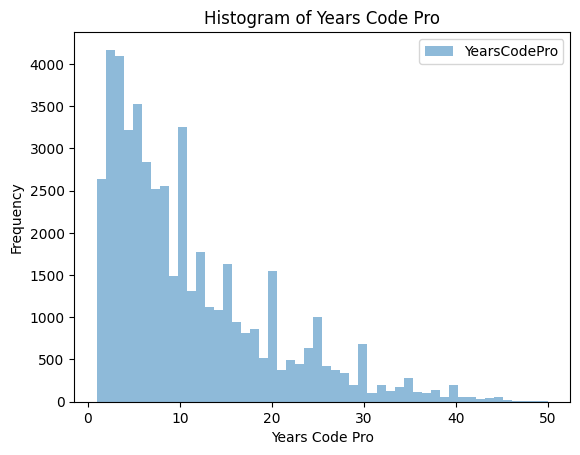

In [36]:
## Write your code here
df_yrscodepro = pd.read_sql("SELECT YearsCodePro FROM main", conn)

# Convert column to numeric, replacing unparseable values with NaN
df_yrscodepro['YearsCodePro'] = pd.to_numeric(df_yrscodepro['YearsCodePro'], errors='coerce')

df_yrscodepro.plot.hist(bins=50, alpha=0.5)
plt.title('Histogram of Years Code Pro')
plt.xlabel('Years Code Pro')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


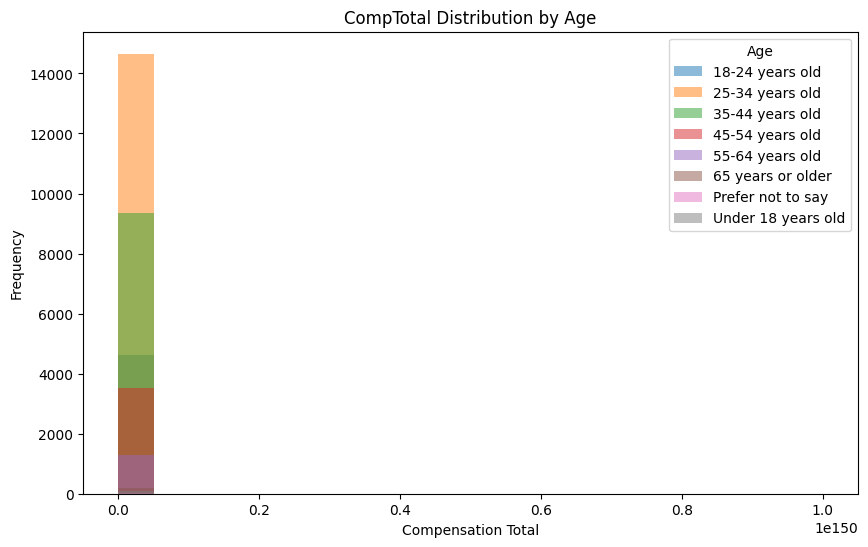

In [37]:
## Write your code here
df_comp_age = pd.read_sql("SELECT CompTotal, Age FROM main", conn)

# 1. Pivot the data: Age (string) becomes columns, CompTotal are values
pivot_df = df_comp_age.pivot(columns='Age', values='CompTotal')

# 2. Plotting as histograms (subplots=True or False depending on preference)
pivot_df.plot.hist(alpha=0.5, bins=20, figsize=(10, 6))

plt.title('CompTotal Distribution by Age')
plt.xlabel('Compensation Total')
plt.ylabel('Frequency')
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


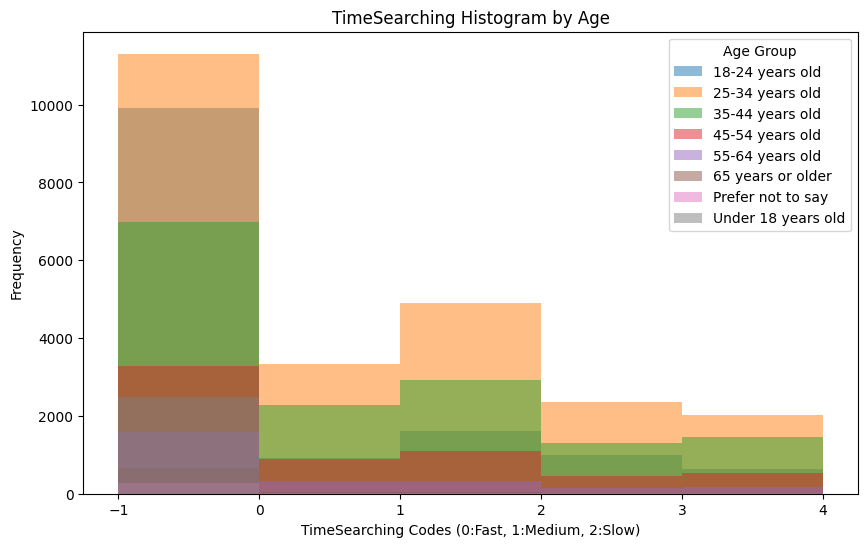

In [38]:
## Write your code here
df_search_age = pd.read_sql("SELECT TimeSearching, Age FROM main", conn)

# Group by 'Age' and extract unique age groups
grouped = df_search_age.groupby('Age')['TimeSearching']

# Plotting
plt.figure(figsize=(10, 6))

for name, group in grouped:
    # Convert string values to codes for plotting
    plt.hist(group.astype('category').cat.codes, bins=5, alpha=0.5, label=name)

plt.title('TimeSearching Histogram by Age')
plt.xlabel('TimeSearching Codes (0:Fast, 1:Medium, 2:Slow)')
plt.ylabel('Frequency')
plt.legend(title='Age Group')
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


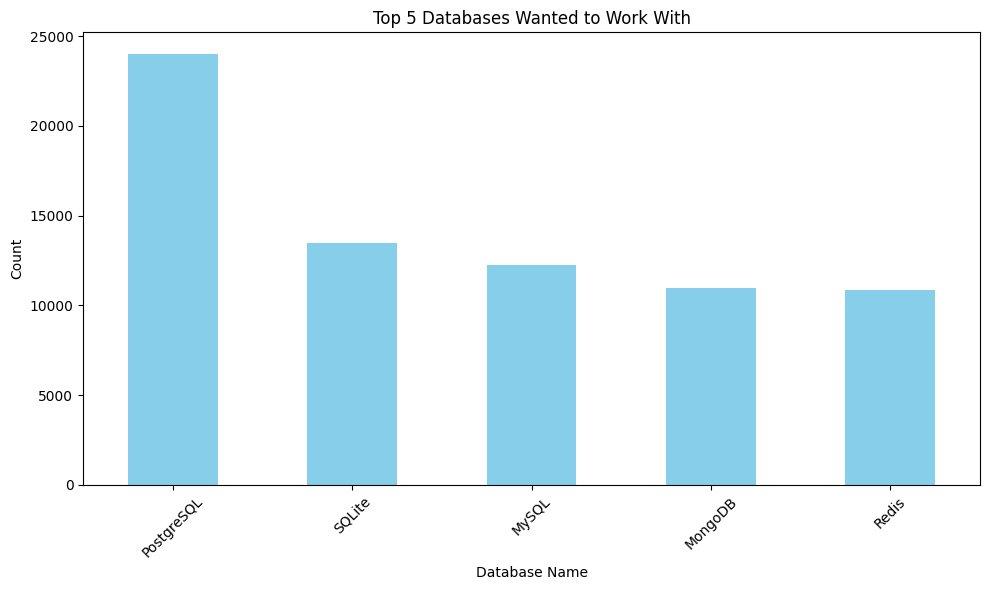

In [42]:
## Write your code here
df_wantwork = pd.read_sql("SELECT DatabaseWantToWorkWith FROM main", conn)

# Split strings by delimiter, flatten lists, get counts
top_5_db = df_wantwork['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(5)

# Plotting
plt.figure(figsize=(10, 6))
top_5_db.plot(kind='bar', color='skyblue')
plt.title('Top 5 Databases Wanted to Work With')
plt.xlabel('Database Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


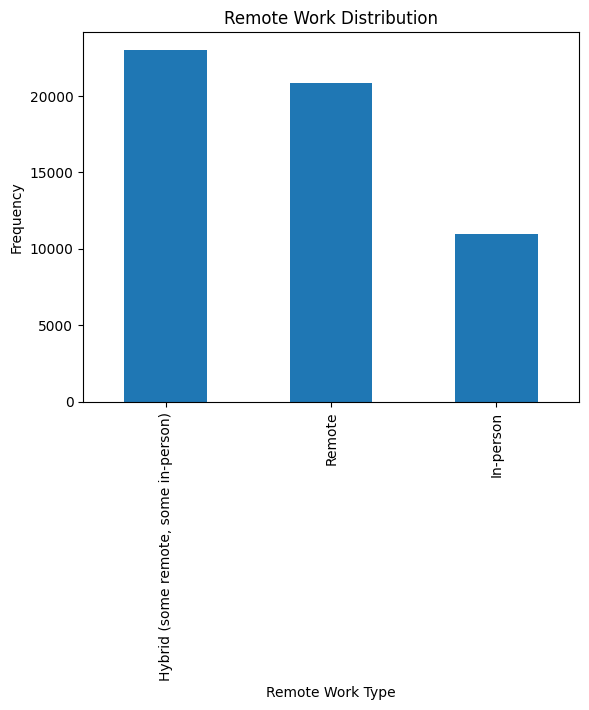

In [44]:
## Write your code here
df_remote = pd.read_sql("SELECT RemoteWork FROM main", conn)
# Count frequencies and plot as bar chart
df_remote['RemoteWork'].value_counts().plot(kind='bar', title='Remote Work Distribution')
plt.ylabel('Frequency')
plt.xlabel('Remote Work Type')
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


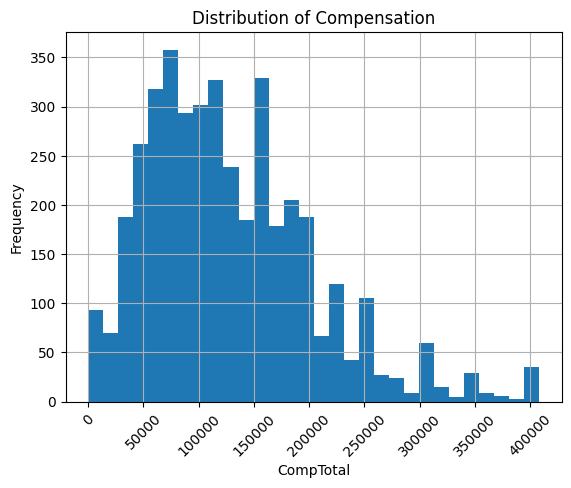

In [60]:
## Write your code here
df_compbyage = pd.read_sql("SELECT CompTotal, Age FROM main", conn)

# 1. Filter the DataFrame for the two specific age groups
filtered_df_compbyage = df_compbyage[df_compbyage['Age'].isin(['45-54 years old', '55-64 years old'])]
filtered_df_compbyage.dropna(inplace=True)
#filtered_df_compbyage.head()

##
df_out = filtered_df_compbyage.copy()

# 1. Calculate IQR for 'CompTotal'
Q1 = df_out['CompTotal'].quantile(0.25)
Q3 = df_out['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Remove outliers
df_out_clean = df_out[(df_out['CompTotal'] >= lower_bound) & (df_out['CompTotal'] <= upper_bound)]

#print(f"Original shape: {df_out.shape}")
#print(f"New shape: {df_out_clean.shape}")

df_out_clean['CompTotal'].hist(bins=30, xrot=45)
plt.title('Distribution of Compensation')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.show()


**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


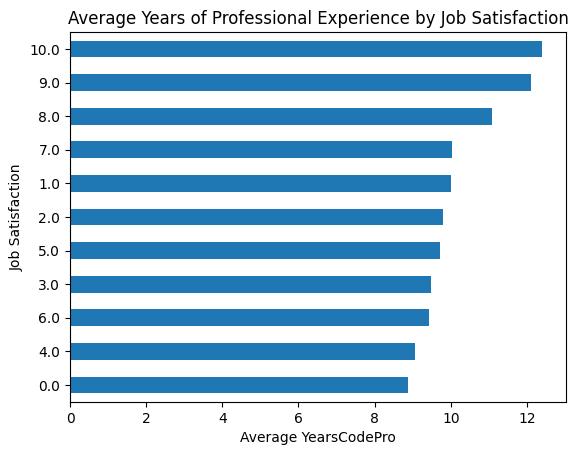

In [68]:
## Write your code here
df_satbyyears = pd.read_sql("SELECT JobSat, YearsCodePro FROM main", conn)
#print(df_satbyyears.head(20))
#print(f"Original shape: {df_satbyyears.shape}")
filtered_df_satbyyears = df_satbyyears
filtered_df_satbyyears.dropna(inplace=True)
#print(filtered_df_satbyyears.head(20))
#print(f"New shape: {filtered_df_satbyyears.shape}")

# Ensure 'YearsCodePro' is numeric before plotting
filtered_df_satbyyears['YearsCodePro'] = pd.to_numeric(filtered_df_satbyyears['YearsCodePro'], errors='coerce')

# Calculate mean, sort for better visualization, and plot
(filtered_df_satbyyears.groupby('JobSat')['YearsCodePro']
 .mean()
 .sort_values()
 .plot(kind='barh', title='Average Years of Professional Experience by Job Satisfaction'))

plt.xlabel('Average YearsCodePro')
plt.ylabel('Job Satisfaction')
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [69]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
